## Importación de librerías

In [2]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

%matplotlib inline
sns.set_theme()


## Carga, agregación a 90 días y purga de datos sensibles

In [3]:
# 1. Cargar datos
vle_df = pd.read_csv('./../../../dataset/oulad/studentVle.csv')
info_df = pd.read_csv('./../../../dataset/oulad/studentInfo.csv')

vle_90_days = vle_df[vle_df['date'] <= 90]
vle_agg = vle_90_days.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_clicks=('sum_click', 'sum'),
    mean_clicks=('sum_click', 'mean'),
    active_days=('date', 'nunique')
).reset_index()

vle_agg.fillna(0, inplace=True)

# 3. Excluir datos sensibles
sensitive_columns = ['gender', 'disability', 'age_band', 'imd_band', 'region']
info_clean = info_df.drop(columns=sensitive_columns)

## Cruce de datos y creación del Target

In [4]:

df_merged = pd.merge(info_clean, vle_agg, on=['id_student', 'code_module', 'code_presentation'], how='inner')

# 2. Definir Agotamiento (Withdrawn = 1, Resto = 0)
df_merged['target_burnout'] = df_merged['final_result'].apply(lambda x: 1 if x == 'Withdrawn' else 0)

# Limpiar columnas innecesarias
df_merged = df_merged.drop(columns=['final_result', 'id_student'])

## Partición por cursos

In [5]:
## Partición por cursos y Balanceo (Undersampling)
import pandas as pd

# 1. Separación temporal inicial (2013 para entrenar, 2014 para evaluar)
df_train = df_merged[df_merged['code_presentation'].str.contains('2013')].copy()
df_test = df_merged[df_merged['code_presentation'].str.contains('2014')].copy()

# ==================================================
# NUEVO: UNDERSAMPLING EN ENTRENAMIENTO (Reducir clase 0)
# ==================================================
# a) Separamos las clases dentro del histórico de 2013
df_train_exito = df_train[df_train['target_burnout'] == 0]
df_train_riesgo = df_train[df_train['target_burnout'] == 1]

# b) Reducimos los casos de éxito a la mitad (frac=0.5) de forma aleatoria
df_train_exito_reducido = df_train_exito.sample(frac=0.5, random_state=42)

# c) Juntamos los de riesgo con el éxito reducido y lo mezclamos (frac=1)
df_train_balanceado = pd.concat([df_train_exito_reducido, df_train_riesgo]).sample(frac=1, random_state=42)
# ==================================================

# 2. Limpiar columnas de metadatos e identificadores
columnas_a_borrar = ['code_module', 'code_presentation']

# 3. Separar matriz de características (X) y variable objetivo (y)
# IMPORTANTE: Ahora el Train sale del dataframe balanceado
X_train = df_train_balanceado.drop(columns=columnas_a_borrar + ['target_burnout'], errors='ignore')
y_train = df_train_balanceado['target_burnout']

# El Test sigue saliendo del dataframe original de 2014 (Realidad pura)
X_test = df_test.drop(columns=columnas_a_borrar + ['target_burnout'], errors='ignore')
y_test = df_test['target_burnout']

print(f"Alumnos en Histórico (Train 2013 Balanceado): {len(X_train)} (Riesgo: {sum(y_train)})")
print(f"Alumnos Nuevos (Test 2014 Real): {len(X_test)} (Riesgo: {sum(y_test)})")

Alumnos en Histórico (Train 2013 Balanceado): 7395 (Riesgo: 2599)
Alumnos Nuevos (Test 2014 Real): 16966 (Riesgo: 4554)


## Construcción y Entrenamiento del Pipeline

In [6]:

# Definición de columnas
cat_cols = ['highest_education']
num_cols = ['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'mean_clicks', 'active_days']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])


"""
 - class_weight: {0: 1, 1: 3}
 - max_depth: 10
 - min_samples_leaf: 5
 - n_estimators: 200
"""

# Pipeline Base Random Forest: 100 árboles y penalización manual para clase Riesgo
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,          # <-- Configuración ganadora
        max_depth=10,              # <-- Configuración ganadora
        min_samples_leaf=5,        # <-- Configuración ganadora
        class_weight={0: 1, 1: 3}, # <-- Configuración ganadora
        random_state=42,           # Mantenemos la semilla para que los resultados no bailen
        n_jobs=-1
    ))
])

# Entrenar modelo
rf_pipeline.fit(X_train, y_train)

# Generar predicciones (Mantenido intacto para que no se rompa la celda 6)
y_pred = rf_pipeline.predict(X_test)

## Evaluación y Gráficas de Rendimiento

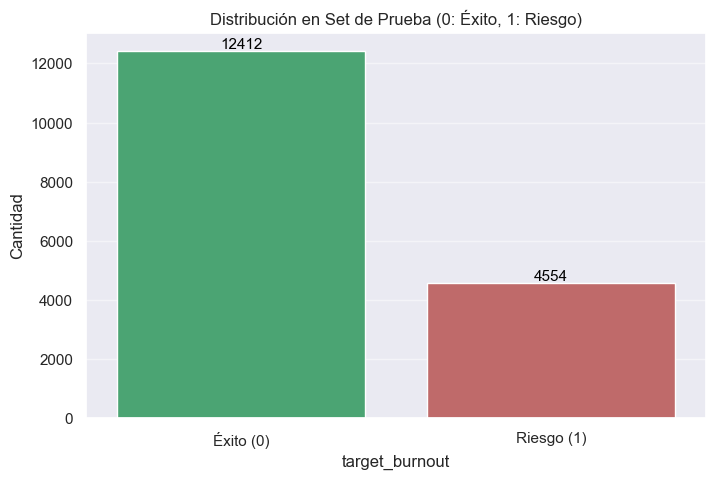

--- REPORTE DE CLASIFICACIÓN DETALLADO (Umbral: 0.52) ---
              precision    recall  f1-score   support

           0       0.86      0.58      0.69     12412
           1       0.39      0.74      0.51      4554

    accuracy                           0.62     16966
   macro avg       0.63      0.66      0.60     16966
weighted avg       0.73      0.62      0.64     16966



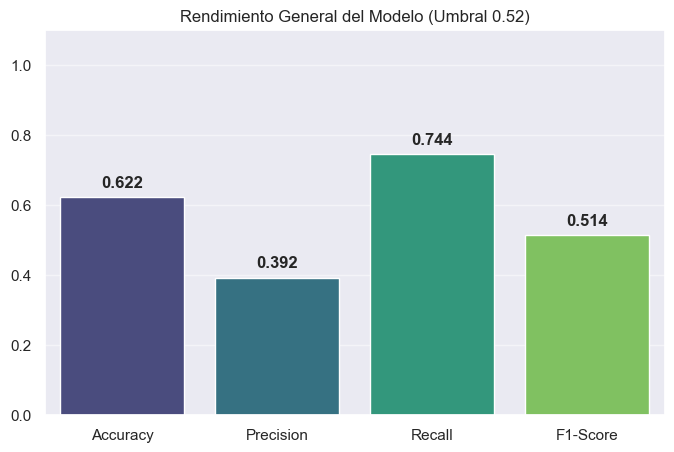

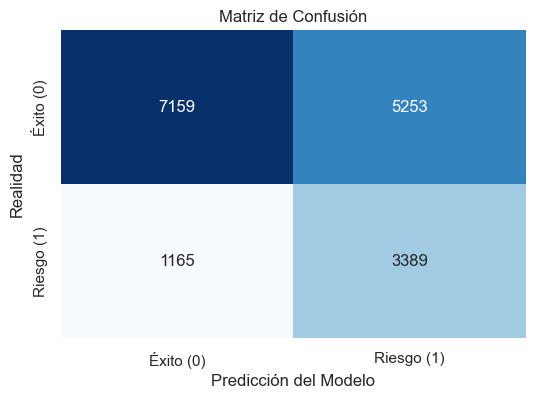

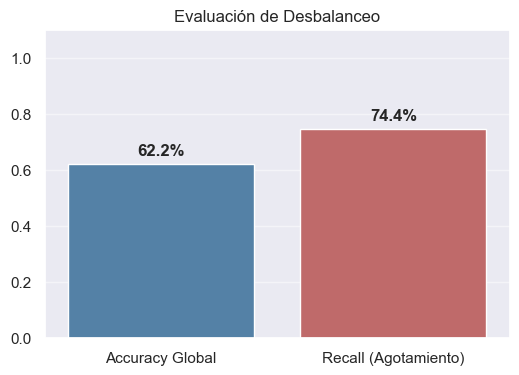

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# NUEVO: CÁLCULO DE PREDICCIONES POR UMBRAL (PARA SUBIR RECALL)
# ==========================================
# Obtenemos las probabilidades de la clase 1 (Riesgo).
# NOTA: Cambia 'nb_pipeline' por 'rf_pipeline' si estás en el script de Random Forest
y_probs = rf_pipeline.predict_proba(X_test)[:, 1]

# UMBRAL PERMISIVO: Ante un 30% de sospecha, clasifica como Riesgo (1).
umbral_permisivo = 0.52
y_pred = (y_probs >= umbral_permisivo).astype(int)

# ==========================================
# GRÁFICO 1: Distribución en el Set de Prueba
# ==========================================
fig1 = plt.figure(figsize=(8, 5))

ax1 = sns.countplot(x=y_test, hue=y_test, palette=['#3CB371', '#CD5C5C'], legend=False)
plt.title('Distribución en Set de Prueba (0: Éxito, 1: Riesgo)')
plt.xticks(ticks=[0, 1], labels=['Éxito (0)', 'Riesgo (1)'])
plt.ylabel('Cantidad')

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

# ==========================================
# CÁLCULO DE MÉTRICAS Y REPORTE
# ==========================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"--- REPORTE DE CLASIFICACIÓN DETALLADO (Umbral: {umbral_permisivo}) ---")
print(classification_report(y_test, y_pred, zero_division=0))

# ==========================================
# GRÁFICO 2: Visualización de Métricas Habituales
# ==========================================
fig2 = plt.figure(figsize=(8, 5))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, prec, rec, f1]
ax2 = sns.barplot(x=metrics_names, y=metrics_values, hue=metrics_names, palette='viridis', legend=False)
plt.title(f'Rendimiento General del Modelo (Umbral {umbral_permisivo})')
plt.ylim(0, 1.1)

for i, v in enumerate(metrics_values):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')
plt.show()

# ==========================================
# GRÁFICO 3: Matriz de Confusión
# ==========================================
cm = confusion_matrix(y_test, y_pred)

fig3 = plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Éxito (0)', 'Riesgo (1)'],
            yticklabels=['Éxito (0)', 'Riesgo (1)'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad')
plt.show()

# ==========================================
# GRÁFICO 4: Accuracy Global vs Recall Minoritario
# ==========================================
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
burnout_recall = report_dict['1']['recall']

fig4 = plt.figure(figsize=(6, 4))

metric_names_comp = ['Accuracy Global', 'Recall (Agotamiento)']
metric_values_comp = [acc, burnout_recall]
ax4 = sns.barplot(x=metric_names_comp, y=metric_values_comp, hue=metric_names_comp, palette=['#4682B4', '#CD5C5C'], legend=False)
plt.title('Evaluación de Desbalanceo')
plt.ylim(0, 1.1)

for i, v in enumerate(metric_values_comp):
    ax4.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.show()